In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Load dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)  # High dimensional
print("Classes:", np.unique(y))


Dataset Shape: (569, 30)
Classes: [0 1]


In [ ]:
# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_classif, k=10)
X_selected = selector.fit_transform(X_scaled, y)

print("Reduced Shape:", X_selected.shape)

Reduced Shape: (569, 10)


In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)



Accuracy: 0.9736842105263158

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


Confusion Matrix:
 [[42  1]
 [ 2 69]]


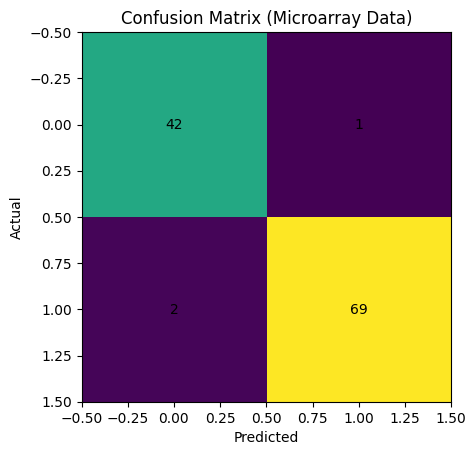

In [ ]:
plt.figure()
plt.imshow(cm)

plt.title("Confusion Matrix (Microarray Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

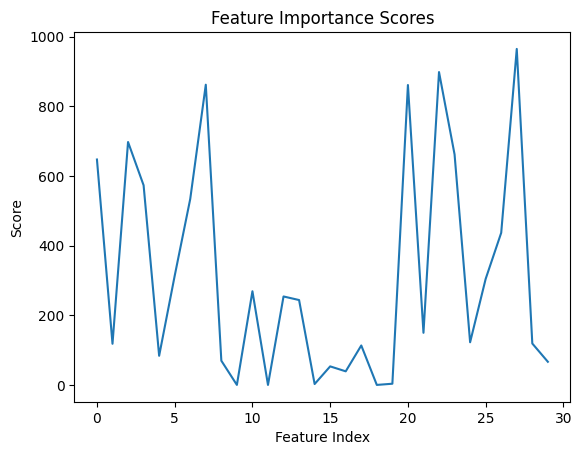

In [ ]:
scores = selector.scores_

plt.figure()
plt.plot(scores)
plt.title("Feature Importance Scores")
plt.xlabel("Feature Index")
plt.ylabel("Score")
plt.show()